# GraphRAG Evaluation with RAGAS

Evaluate the GraphRAG pipeline using RAGAS metrics:
- **Faithfulness**: How grounded the answer is in the context
- **Answer Relevancy**: How relevant the answer is to the question
- **Context Precision**: How precise the retrieved contexts are
- **Context Recall**: How well contexts recall relevant information

In [1]:
!pip install -q ragas datasets evaluate


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

def load_dotenv(path=".env"):
    if os.path.exists(path):
        with open(path) as f:
            for line in f:
                line = line.strip()
                if line and not line.startswith("#") and "=" in line:
                    key, val = line.split("=", 1)
                    os.environ.setdefault(key.strip(), val.strip().strip("'\""))

load_dotenv()
print(f"GROQ_API_KEY: {'set' if os.environ.get('GROQ_API_KEY') else 'MISSING'}")

GROQ_API_KEY: set


In [3]:
from graphrag import GraphRAG

engine = GraphRAG()
print(f"Engine ready: {engine.page_count} pages, {engine.chunk_count} chunks")

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Engine ready: 2 pages, 30 chunks


In [4]:
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import HuggingfaceEmbeddings
from ragas.run_config import RunConfig
from datasets import Dataset
from graphrag import get_llm

run_config = RunConfig(timeout=600, max_retries=5, max_workers=4)
llm = LangchainLLMWrapper(get_llm(), run_config=run_config)
embeddings = HuggingfaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

faithfulness.llm = llm
answer_relevancy.llm = llm
context_precision.llm = llm
context_recall.llm = llm

faithfulness.embeddings = embeddings
answer_relevancy.embeddings = embeddings
context_precision.embeddings = embeddings
context_recall.embeddings = embeddings

print("RAGAS metrics configured with Groq LLM and HuggingFace embeddings")

RAGAS metrics configured with Groq LLM and HuggingFace embeddings


In [5]:
questions = [
    "What is GraphRAG and how does it work?",
    "Explain hybrid retrieval with BM25 and ChromaDB",
    "What are the key features of self-corrective RAG?",
]

ground_truths = [
    "GraphRAG is an advanced agentic RAG framework featuring hybrid retrieval, Pydantic structured grading, self-corrective loops, and web search fallback.",
    "Hybrid retrieval combines BM25 sparse keyword search with ChromaDB dense semantic search using Reciprocal Rank Fusion for superior ranked results.",
    "Self-corrective RAG features automated retry on hallucination detection, document relevance grading, and web search fallback when local retrieval fails.",
]

print(f"Evaluating {len(questions)} questions...")

Evaluating 3 questions...


In [6]:
answers = []
contexts = []

for i, q in enumerate(questions):
    print(f"  [{i+1}/{len(questions)}] Running: {q[:50]}...", end=" ")
    result = engine.ask(q)
    answers.append(result["generation"])
    contexts.append([doc.page_content for doc in result.get("documents", [])[:5]])
    print("done")

dataset = Dataset.from_dict({
    "question": questions,
    "answer": answers,
    "contexts": contexts,
    "ground_truth": ground_truths,
})
print(f"\nDataset ready: {len(dataset)} samples")

  [1/3] Running: What is GraphRAG and how does it work?... 

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `qwen/qwen3.6-27b` in organization `org_01keq0t1cne2p93g802mxenaz8` service tier `on_demand` on tokens per day (TPD): Limit 200000, Used 198917, Requested 2304. Please try again in 8m47.472s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [ ]:
result = evaluate(
    dataset=dataset,
    metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
    embeddings=embeddings,
    run_config=run_config,
)

print("=" * 50)
print("RAGAS EVALUATION RESULTS")
print("=" * 50)
print(f"Faithfulness:      {result['faithfulness']:.2%}")
print(f"Answer Relevancy:  {result['answer_relevancy']:.2%}")
print(f"Context Precision: {result['context_precision']:.2%}")
print(f"Context Recall:    {result['context_recall']:.2%}")
print("=" * 50)

Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

Exception raised in Job[2]: TimeoutError()
Exception raised in Job[1]: TimeoutError()
Exception raised in Job[8]: TimeoutError()
Exception raised in Job[5]: TimeoutError()
Exception raised in Job[9]: TimeoutError()
Exception raised in Job[3]: TimeoutError()
Exception raised in Job[4]: TimeoutError()
Exception raised in Job[10]: TimeoutError()
Exception raised in Job[0]: TimeoutError()


RAGAS EVALUATION RESULTS
Faithfulness:      nan%
Answer Relevancy:  nan%
Context Precision: 100.00%
Context Recall:    50.00%


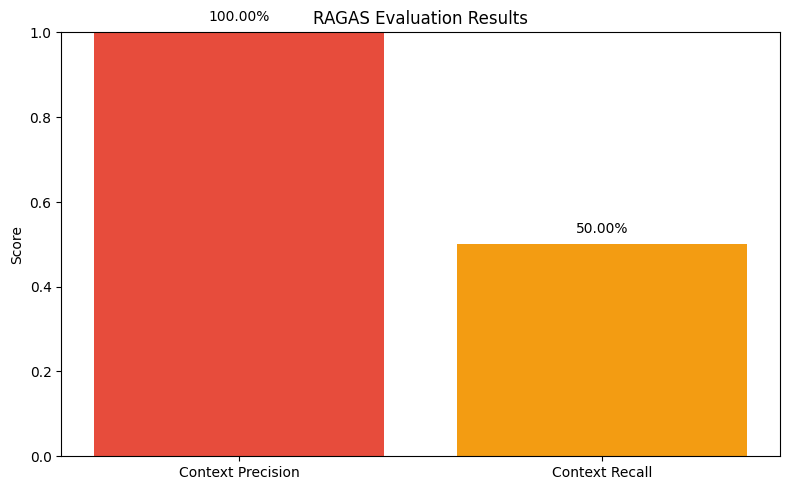

In [ ]:
try:
    import matplotlib.pyplot as plt

    metrics_names = ['Faithfulness', 'Answer Relevancy', 'Context Precision', 'Context Recall']
    scores = [result['faithfulness'], result['answer_relevancy'], result['context_precision'], result['context_recall']]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(metrics_names, scores, color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score')
    ax.set_title('RAGAS Evaluation Results')

    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{score:.2%}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()
except ImportError:
    print("pip install matplotlib for visualization")